In [1]:
import xarray as xr
import scipy
import numpy as np
import pandas as pd
import copy
from datetime import datetime
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import pandas as pd
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import numpy as np
import pandas as pd
from typing import Tuple
import torch
from sklearn.linear_model import LinearRegression
import proto_scales.data_prep.prepare_data as prep
import pickle

In [78]:
MODEL = 'ACCESS-ESM1-5'#''MPI-ESM1-2-LR'#'ACCESS-ESM1-5'#'CanESM5'#'MIROC6'
INDICATORS = ['tas','pr']
TEST_SCENARIOS = ['ssp245']
TRAIN_SCENARIOS = [ 'ssp585','1pctco2']#,'ssp534-over','flat10cdrincspinoff','ssp126','flat10zecincspinoff', 'flat10cdrincspinoff']#,'abrupt4xco2','ssp119','ssp460','ssp370']
N = 200 
PATTERN_SCALING_RESIDUALS = False
RAMP_DOWN_CORRECTED_PS = False
monthly_flag = True
use_smoothing = False
train_pattern_scaling_name = 'ssp585'

MODEL_PATH = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{MODEL}'

In [79]:
test_data_np = prep.fetch_and_massage_data(
    model_path=MODEL_PATH,
    indicators=INDICATORS,
    train_scenarios=TEST_SCENARIOS,
    monthly_flag=monthly_flag,
    use_smoothing=use_smoothing,
    train_pattern_scaling_name=train_pattern_scaling_name,
    pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS,
    ramp_down_corrected_ps=RAMP_DOWN_CORRECTED_PS,
)

test_data_np = np.array(test_data_np)
test_gmt = test_data_np[:,0,:]
test_data_np = test_data_np[:,1:,:]
print(test_data_np.shape)
regions = int(test_data_np.shape[1]/2)
tas_test = test_data_np[:,:regions,:]
tas_test = np.transpose(tas_test,(0, 2, 1))
pr_test = test_data_np[:,-regions:,:]
pr_test = np.transpose(pr_test,(0, 2, 1))
print(test_gmt.shape,tas_test.shape)

(40, 116, 3012)
(40, 3012) (40, 3012, 58)


In [4]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB']

In [8]:
device = "cpu"
Dy = tas_test.shape[-1]
Du = 1#test_gmt.shape[-1]

# model = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
#                                  emission_uses_u=emission_uses_u).to(device)
model_ssm = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
                                 emission_uses_u=emission_uses_u,reservoir_dim=resevoir_dim,alpha_max=alpha_max).to(device)


model = DeepCnpSsmforESM(ssm_model=model_ssm,r_dim = 128, z_cnp_dim=32)  
model.load_state_dict(torch.load(model_filename, map_location=torch.device(device)))
model.eval()

DeepCnpSsmforESM(
  (ssm): DeepSSMPatternConditioned(
    (gru): GRU(59, 256, batch_first=True)
    (q_head): Linear(in_features=256, out_features=128, bias=True)
    (trans): MLP(
      (net): Sequential(
        (0): Linear(in_features=65, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (u_gru): GRU(1, 64, batch_first=True)
    (omega_lin): Linear(in_features=64, out_features=232, bias=False)
    (emit): MLP(
      (net): Sequential(
        (0): Linear(in_features=360, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
        (4): Linear(in_features=128, out_features=116, bias=True)
      )
    )
    (emit_pr): MLP(
      (net): Sequential(
        (0): Linear(in_features=360, out_features=230, bias=True)
        (1): SiLU()
      

In [9]:
def center_histogram(histo: np.ndarray, bin_edges: np.ndarray):
    bins_centre = []
    for k in range(1, len(bin_edges)):
        bins_centre.append((bin_edges[k] + bin_edges[k - 1]) / 2.)
    return histo, bins_centre

def get_hist_vec(data, bins=10, rangeH=None, density=True):
    histo, bin_edge = np.histogram(data, bins=bins, range=rangeH, density=density)
    return center_histogram(histo, bin_edge)

def get_hist_vec_cum(data, bins=10, rangeH=None, density=True, cumulative=True):
    histo, bin_edge, _ = plt.hist(data, bins=bins, range=rangeH, density=density, cumulative=cumulative)
    plt.clf()
    return center_histogram(histo, bin_edge)

In [12]:
def get_variability_from_data(n_first_indices,y_gt):
    monthly_data=[]
    for i in range(12):
        monthly_data.append([])
        for j in np.arange(i,n_first_indices,12):
            monthly_data[i].append(y_gt[j])
        
    variability = np.zeros_like(y_gt)
    
    for i in range(12):
        for j in np.arange(i,len(variability),12):
            variability[j]=np.std(np.array(monthly_data[i]))
    return variability

In [14]:
Generation of ensemble data

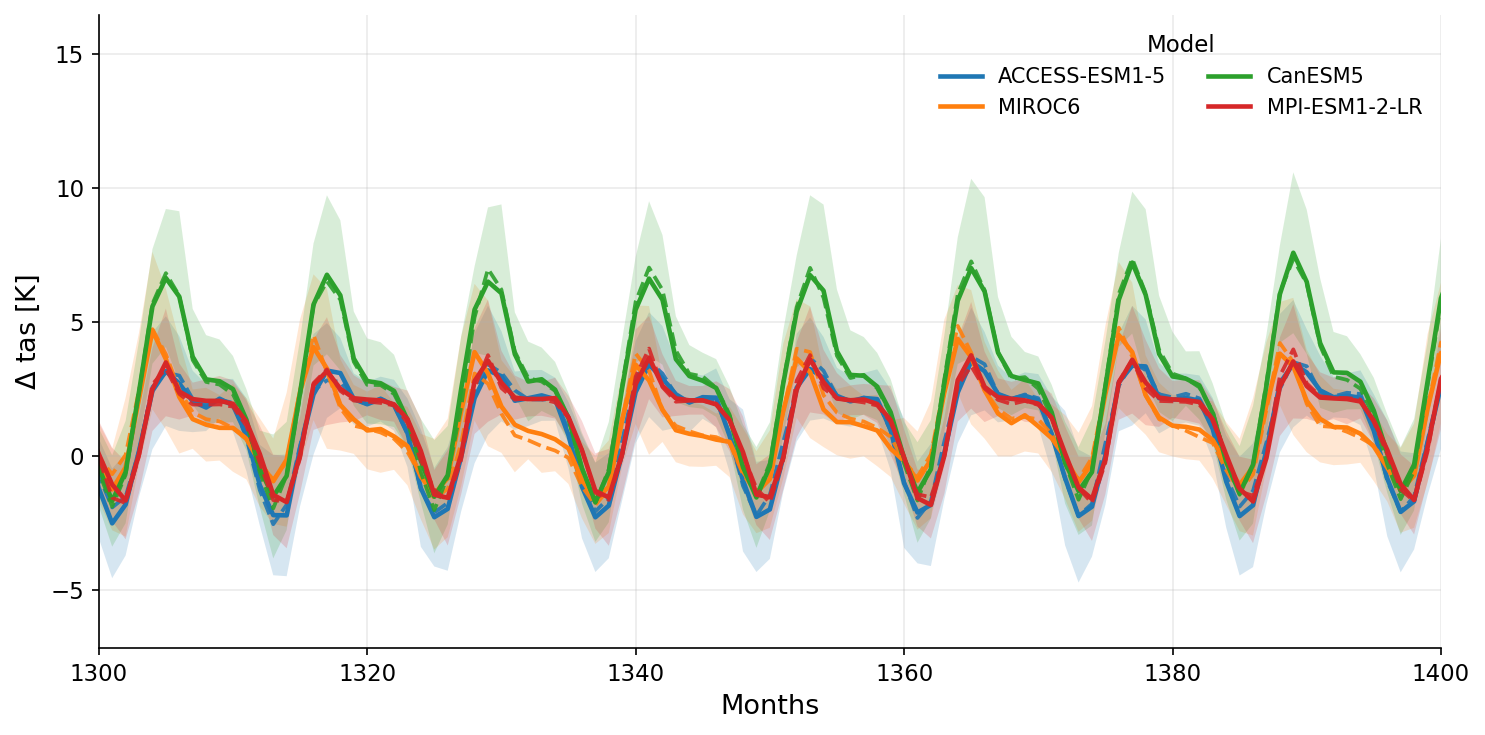

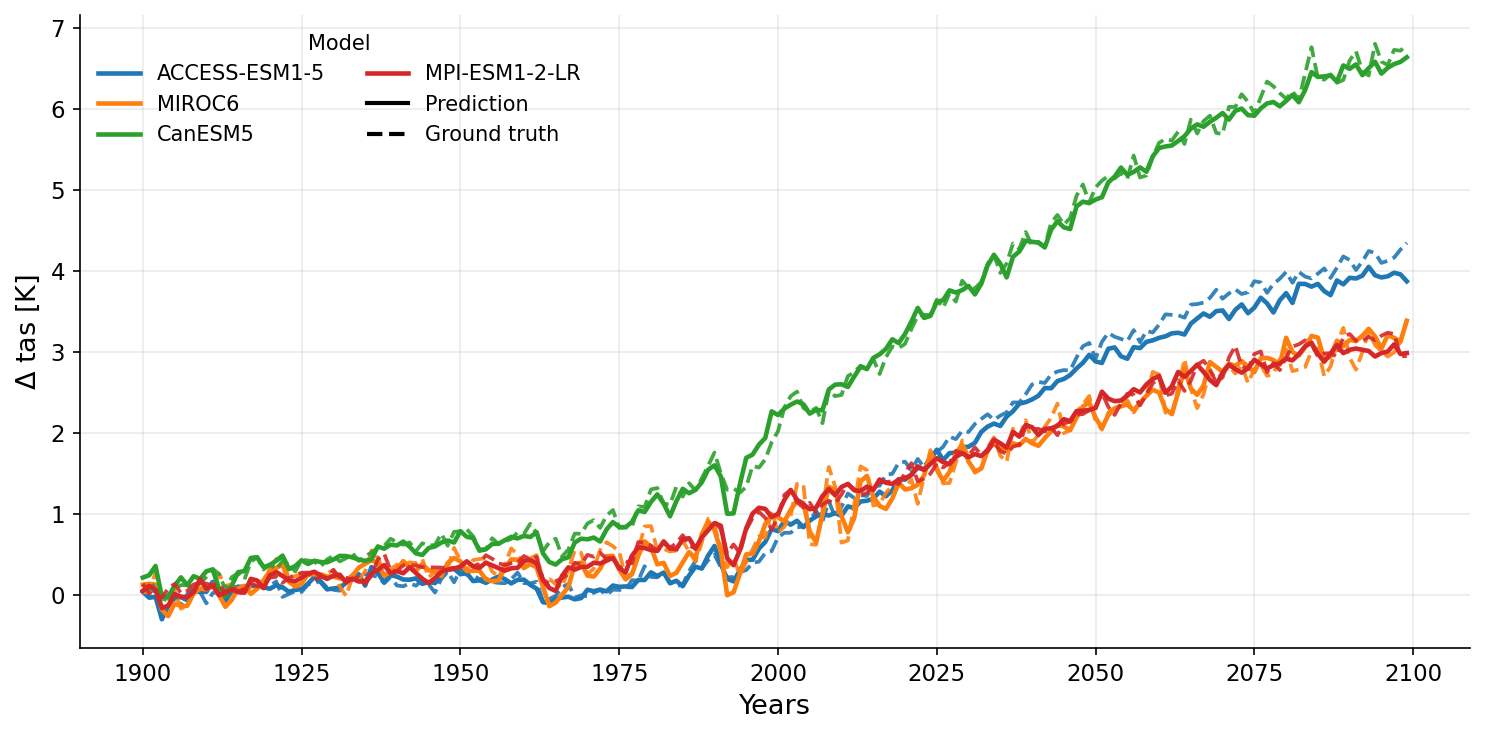

In [8]:
import pickle
pickle_filename =[]

pickle_filename.append("/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/ACCESS/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl")
pickle_filename.append("/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/MIROC6/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl")
pickle_filename.append("/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/CanESM5/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl")
pickle_filename.append("/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/MPI-ESM1-2-LR/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl")

pred_data = {}


for i,val in enumerate(pickle_filename):
    data = pickle.load( open(val, "rb") ) 
    name = val.replace("/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/","").replace("/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl","")
    pred_data[name] = data


region = region_names.index("SAM")


# fig = plt.figure()
# plt.xlim([1300,1400])
# plt.xlabel("Months", fontsize=14)
# plt.ylabel("$\Delta$ tas [K]", fontsize=14)
# for i,val in enumerate(pred_data.keys()):
#     name = val
#     if "ACCESS" in val:
#         name = "ACCESS-ESM1-5"
#     sigma = np.std(pred_data[val]["tas"][:,:,region],axis = 0)
#     mean =  np.mean(pred_data[val]["tas"][:,:,region],axis = 0)
#     mean_gt = np.mean(pred_data[val]["tas_gt"][:,:,region],axis = 0)
#     pred_data[val]["mean_tas"] = mean
#     pred_data[val]["sigma_tas"] = sigma
#     pred_data[val]["mean_tas_gt"] = mean_gt
#     plot = plt.plot(mean,label=name)
#     plot = plt.plot(mean_gt,color = plot[0].get_color(),ls="--")
#     plt.fill_between(
#         np.arange(0,len(mean),1),
#         mean-2*sigma,
#         mean+2*sigma,
#         color=plot[0].get_color(),
#         alpha=0.25,
#     )
# plt.legend()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

ax.set_xlim(1300, 1400)
ax.set_xlabel("Months", fontsize=13)
ax.set_ylabel(r"$\Delta$ tas [K]", fontsize=13)

for model, data in pred_data.items():
    label = "ACCESS-ESM1-5" if "ACCESS" in model else model

    tas = data["tas"][:, :, region]
    tas_gt = data["tas_gt"][:, :, region]

    mean = np.mean(tas, axis=0)
    sigma = np.std(tas, axis=0)
    mean_gt = np.mean(tas_gt, axis=0)

    pred_data[model]["mean_tas"] = mean
    pred_data[model]["sigma_tas"] = sigma
    pred_data[model]["mean_tas_gt"] = mean_gt

    x = np.arange(len(mean))

    line, = ax.plot(x, mean, lw=2.2, label=label)
    ax.plot(x, mean_gt, color=line.get_color(), lw=1.8, ls="--", alpha=0.9)

    ax.fill_between(
        x,
        mean - 2 * sigma,
        mean + 2 * sigma,
        color=line.get_color(),
        alpha=0.18,
        linewidth=0,
    )

ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=10,
    ncol=2,
    loc="best",
    title="Model",
    title_fontsize=11,
)

ax.tick_params(axis="both", labelsize=11)
fig.tight_layout()
#fig.savefig("/home/kainverena/PythonProjects/scales_plots/cnp_tas_region_SAM_monthly.pdf", dpi=300, bbox_inches="tight")


# fig = plt.figure()
# plt.xlabel("Years", fontsize=14)
# plt.ylabel("$\Delta$ tas [K]", fontsize=14)
# for i,val in enumerate(pred_data.keys()):
#     name = val
#     if "ACCESS" in val:
#         name = "ACCESS-ESM1-5"
#     tas_yearly_mean = [np.mean(pred_data[val]["mean_tas"][i-12:i]) for i in np.arange(12,len(pred_data[val]["mean_tas"]),12)]
#     tas_yearly_mean_gt = [np.mean(pred_data[val]["mean_tas_gt"][i-12:i]) for i in np.arange(12,len(pred_data[val]["mean_tas_gt"]),12)]
#     plot = plt.plot(tas_yearly_mean,label=name)
#     plt.plot(tas_yearly_mean_gt,color = plot[0].get_color(),ls="--")

# plt.legend()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

ax.set_xlabel("Years", fontsize=13)
ax.set_ylabel(r"$\Delta$ tas [K]", fontsize=13)

for model, data in pred_data.items():
    label = "ACCESS-ESM1-5" if "ACCESS" in model else model

    # Annual means from monthly data
    tas_yearly_mean = np.array([
        np.mean(data["mean_tas"][i-12:i])
        for i in range(12, len(data["mean_tas"]) + 1, 12)
    ])

    tas_yearly_mean_gt = np.array([
        np.mean(data["mean_tas_gt"][i-12:i])
        for i in range(12, len(data["mean_tas_gt"]) + 1, 12)
    ])
    start_year = 1850+600/12
    years = np.arange(start_year, start_year + len(tas_yearly_mean))
    #years = np.arange(len(tas_yearly_mean))

    line, = ax.plot(
        years,
        tas_yearly_mean,
        lw=2.2,
        label=label,
    )

    ax.plot(
        years,
        tas_yearly_mean_gt,
        color=line.get_color(),
        ls="--",
        lw=1.8,
        alpha=0.9,
    )

ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=11)

from matplotlib.lines import Line2D

handles, labels = ax.get_legend_handles_labels()

style_handles = [
    Line2D([0], [0], color="k", lw=2, label="Prediction"),
    Line2D([0], [0], color="k", lw=2, ls="--", label="Ground truth"),
]

ax.legend(
    handles=handles + style_handles,
    frameon=False,
    ncol=2,
    fontsize=10,
    title="Model",
)

fig.tight_layout()
#fig.savefig("/home/kainverena/PythonProjects/scales_plots/cnp_tas_region_SAM_yearly_trend.pdf", dpi=300, bbox_inches="tight")



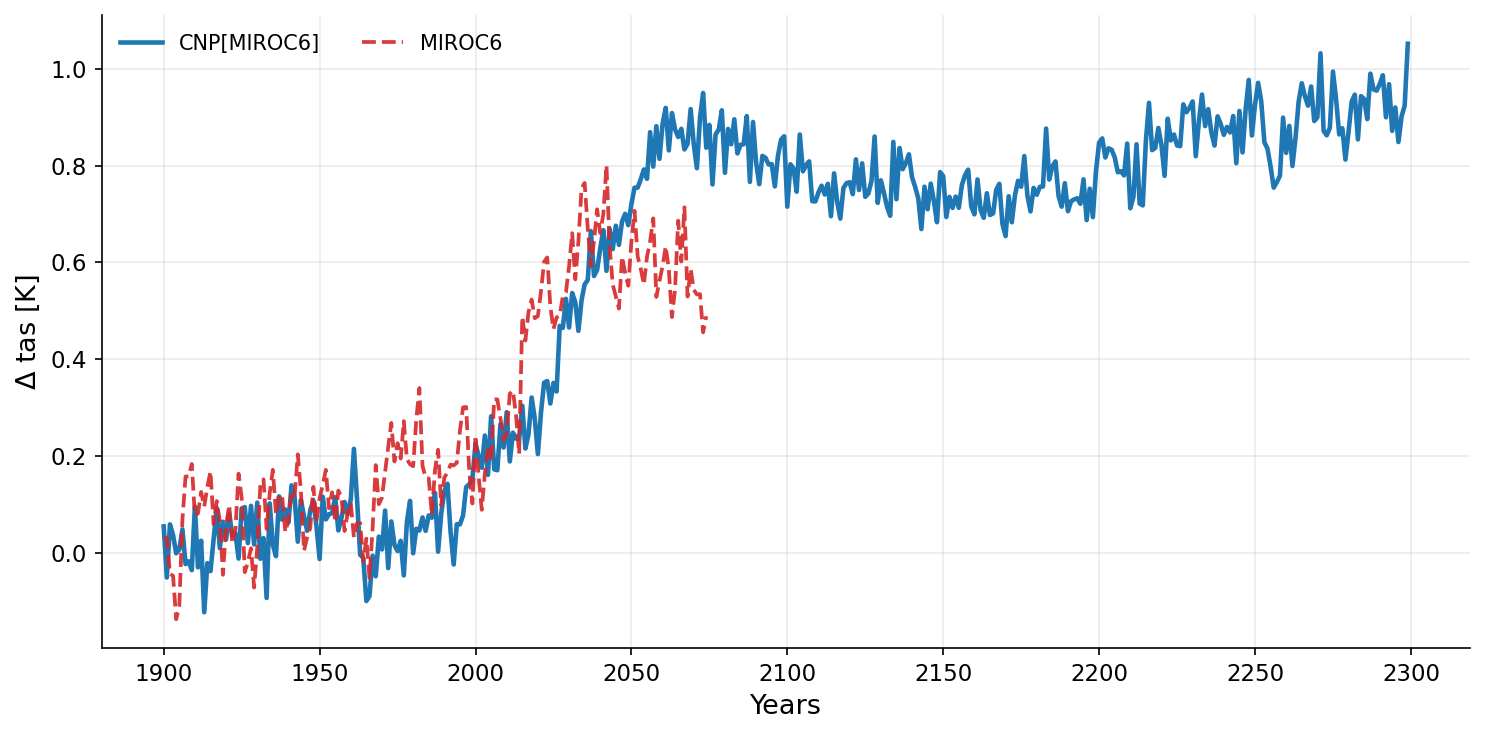

In [15]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
pickle_filename = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/MIROC6/ssp534-over_pr_tas_monthly_cnp_4800m_30Jun26.pkl"

data = pickle.load( open(pickle_filename, "rb") ) 
region = region_names.index("SOO")

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

ax.set_xlabel("Years", fontsize=13)
ax.set_ylabel(r"$\Delta$ tas [K]", fontsize=13)

tas = data["tas"][:, :, region]
tas_gt = data["tas_gt"][:, :, region]


mean = np.mean(tas, axis=0)
sigma = np.std(tas, axis=0)
mean_gt = np.mean(tas_gt, axis=0)



# Annual means from monthly data
tas_yearly_mean = np.array([
    np.mean(mean[i-12:i])
    for i in range(12, len(mean) + 1, 12)
])

tas_yearly_mean_gt = np.array([
    np.mean(mean_gt[i-12:i])
    for i in range(12, len(mean_gt) + 1, 12)
])
start_year = 1850+600/12
years = np.arange(start_year, start_year + len(tas_yearly_mean))
#years = np.arange(len(tas_yearly_mean))



line, = ax.plot(
    years,
    tas_yearly_mean,
    lw=2.2,
    color="#1f77b4",
    label="CNP[MIROC6]",
)

ax.plot(
    years[:len(tas_yearly_mean_gt)],
    tas_yearly_mean_gt,
    ls="--",
    lw=1.8,
    alpha=0.9,
    color="#d62728", 
    label = "MIROC6"
)

ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=11)

from matplotlib.lines import Line2D

handles, labels = ax.get_legend_handles_labels()


ax.legend(
    handles=handles,
    frameon=False,
    ncol=2,
    fontsize=10,
)

fig.tight_layout()
#plt.savefig("/home/kainverena/PythonProjects/scales_plots/cnp_tas_region_SOO_MIROC6_access_ssp534-over.pdf", dpi=300, bbox_inches="tight")

In [52]:
#Check reading in ESM data
from proto_scales.multi_esm_model.scales_cnp import build_task_dict


models = ['CanESM5','ACCESS-ESM1-5','MPI-ESM1-2-LR','MIROC6']
weights = [1.,1.,1.,1.]
INDICATORS = ['tas','pr']
TRAIN_SCENARIOS = [ 'ssp534-over','ssp585','ssp370','ssp460','1pctco2','abrupt-4xco2','flat10zecincspinoff','flat10cdrincspinoff','ssp126']#,'1pctco2','ssp460','ssp534-over','abrupt-4xco2','flat10zecincspinoff','flat10cdrincspinoff','ssp126','ssp370']
  
esm_data = {}

for i,model in enumerate(models):
    task_data = {}
    model_path = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{model}'

    u,tas,pr=prep.prepare_ds_data(
        model_path = model_path,
        train_scenarios=TRAIN_SCENARIOS,
        indicators=INDICATORS,
        sample_length=1800,
        n_skip=450,
        )
    task_data['y'] = tas
    task_data['pr'] = pr
    task_data['u'] = u
    task_data['weight'] = weights[i]
    esm_data[model] = task_data

Dy = tas.shape[-1]
Du = u.shape[-1]

tasks,scalers = build_task_dict(esm_data=esm_data,context_len=600,horizon=1200)

Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble


/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline

Info: Exact ensemble match not found. Using 'access-esm1-5_picontrol-r1i1p1f1_tas_ipcc-regions_latweight.csv' with different ensemble


/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:343: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_experiment = pd.read_csv(experiment_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(base

In [53]:
print(len(tasks['MPI-ESM1-2-LR']['support']))
print(len(tasks['ACCESS-ESM1-5']['support']))
print(len(tasks['CanESM5']['support']))
print(len(tasks['MIROC6']['support']))

203
700
392
234
